In [2]:
import psutil
import sys
# !{sys.executable} --version
# !{sys.executable} -m pip install shap --upgrade 
import joblib
import time
from shutil import copy
import numpy as np
import pandas as pd
import random
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

from tqdm.notebook import tqdm
import seaborn as sns
from collections import Counter

from glob import glob
import psi4
from helper_CC_ML_spacial import *

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline

In [53]:
# Most important features (top 5 by SHAP):
# doublecheck: Numerator of the MP2 t2-amplitude, two-electron integral <ik || ab>
# t2start: Initial MP2 t2-amplitude
# t2mag: Magnitude of the MP2 t2-amplitude
# orbdiff: Denominator of the MP2 t2-amplitude
# diag: Binary feature denoting whether a=b (virtual orbits are the same)
top5 = ['doublecheck', 't2start', 't2mag', 'orbdiff', 'diag']

# 31 Features order in X, including t2
properties=['Evir1', 'Hvir1', 'Jvir1', 'Kvir1', 'Evir2', 'Hvir2', 'Jvir2', 'Kvir2', 'Eocc1', 'Jocc1', 'Kocc1', 'Hocc1','Eocc2', 'Jocc2', 'Kocc2', 'Hocc2', 'Jia1', 'Jia2', 'Kia1', 'Kia2','diag', 'orbdiff', 'doublecheck', 't2start', 't2mag', 't2sign', 'Jia1mag', 'Jia2mag','Kia1mag', 'Kia2mag','t2']

In [5]:
basis_sets = ['STO-3G', 'cc-pVDZ', 'aug-cc-pVDZ']

In [6]:
molecules = ["water", "methanol", "ethylene", "ethane", "methane", "ammonia", "formaldehyde"]

In [9]:
random.seed(0)
all_sampled_files = []

all_files = sorted(glob(os.path.join("data", f"water*.xyz")))
sample_size = min(150, len(all_files))
sampled_files = random.sample(all_files, sample_size)
train = sampled_files[:100]
test = sampled_files[100:]

In [10]:
train

['data/water189.xyz',
 'data/water93.xyz',
 'data/water197.xyz',
 'data/water109.xyz',
 'data/water16.xyz',
 'data/water35.xyz',
 'data/water3.xyz',
 'data/water193.xyz',
 'data/water17.xyz',
 'data/water28.xyz',
 'data/water182.xyz',
 'data/water52.xyz',
 'data/water15.xyz',
 'data/water34.xyz',
 'data/water131.xyz',
 'data/water165.xyz',
 'data/water86.xyz',
 'data/water121.xyz',
 'data/water60.xyz',
 'data/water158.xyz',
 'data/water40.xyz',
 'data/water57.xyz',
 'data/water133.xyz',
 'data/water171.xyz',
 'data/water122.xyz',
 'data/water116.xyz',
 'data/water176.xyz',
 'data/water26.xyz',
 'data/water47.xyz',
 'data/water77.xyz',
 'data/water181.xyz',
 'data/water20.xyz',
 'data/water172.xyz',
 'data/water59.xyz',
 'data/water65.xyz',
 'data/water147.xyz',
 'data/water45.xyz',
 'data/water90.xyz',
 'data/water201.xyz',
 'data/water38.xyz',
 'data/water95.xyz',
 'data/water113.xyz',
 'data/water44.xyz',
 'data/water102.xyz',
 'data/water120.xyz',
 'data/water192.xyz',
 'data/water1

In [11]:
test

['data/water160.xyz',
 'data/water84.xyz',
 'data/water62.xyz',
 'data/water98.xyz',
 'data/water80.xyz',
 'data/water70.xyz',
 'data/water168.xyz',
 'data/water148.xyz',
 'data/water39.xyz',
 'data/water19.xyz',
 'data/water151.xyz',
 'data/water157.xyz',
 'data/water22.xyz',
 'data/water174.xyz',
 'data/water140.xyz',
 'data/water196.xyz',
 'data/water137.xyz',
 'data/water23.xyz',
 'data/water112.xyz',
 'data/water54.xyz',
 'data/water185.xyz',
 'data/water138.xyz',
 'data/water27.xyz',
 'data/water63.xyz',
 'data/water101.xyz',
 'data/water130.xyz',
 'data/water92.xyz',
 'data/water125.xyz',
 'data/water142.xyz',
 'data/water119.xyz',
 'data/water78.xyz',
 'data/water149.xyz',
 'data/water106.xyz',
 'data/water110.xyz',
 'data/water76.xyz',
 'data/water41.xyz',
 'data/water104.xyz',
 'data/water108.xyz',
 'data/water100.xyz',
 'data/water161.xyz',
 'data/water56.xyz',
 'data/water190.xyz',
 'data/water134.xyz',
 'data/water184.xyz',
 'data/water48.xyz',
 'data/water50.xyz',
 'data/

In [13]:
X_test_all = {}
y_test_all = {}
basis_sets = ["STO-3G"]
for basis in basis_sets:
    filenames = test.copy()
    t1 = time.time()
    print(basis)

    data_dict = {}
    for fn in filenames:
        struct = os.path.basename(fn)
        print(f"Processing {struct}")
        
        with open(fn,'r') as f:
            text=f.read()
        
        mol = psi4.geometry(text)
        
        psi4.core.clean()
        psi4.core.be_quiet()
        
        psi4.set_options({'basis': basis,
                          'scf_type': 'pk',
                          'reference': 'rohf',
                          'mp2_type': 'conv',
                          'e_convergence': 1e-8,
                          'd_convergence': 1e-8})

        try:
            rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
            scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
            
            A = HelperCCEnergy(mol, rhf_e, scf_wfn, freeze_core=False)

            MP2T2=A.t2start
            A.t1 = np.zeros((A.t1.shape))
            A.t2 = MP2T2
            
            MP2E = A.compute_energy(iterate=False)                    # MP2 (initial) energy
            CCSDE = A.compute_energy()                                   # exact CCSD energy

            data = pd.DataFrame(np.array([getattr(A, attr).flatten() for attr in properties]).T, columns=properties)
            data_dict[struct.split('_')[0]] = data

        except Exception as e:
            print(f"Molecule with filename {fn} failed: {e}")
            pass   

    X_test_all[basis] = np.vstack([df[top5].to_numpy() for df in data_dict.values()])
    y_test_all[basis] = np.concatenate([df["t2"].to_numpy().reshape(-1) for df in data_dict.values()])

        
    splits = {
        'X_test': X_test_all[basis],
        'y_test': y_test_all[basis]
    }
    
    joblib.dump(splits, f"water_out/{basis}_test_data_splits.pkl")
    t2 = time.time()

    print(f"Time taken for {basis}: {t2-t1} seconds \n")

STO-3G
Processing water160.xyz
Computing RHF reference.


/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.024 seconds.

CCSD Iteration   0: CCSD correlation = -0.034939300303044   dE =  3.49393E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034939300303044   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034939300303044   dE =  3.49393E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044234777738299   dE = -9.29548E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047131565832642   dE = -2.89679E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048690563634790   dE = -1.55900E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048806418191053   dE = -1.15855E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048813868675304   dE = -7.45048E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048811700649557   d

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.008 seconds.

CCSD Iteration   0: CCSD correlation = -0.034853190220114   dE =  3.48532E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034853190220114   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034853190220114   dE =  3.48532E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044112278142547   dE = -9.25909E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046992640534825   dE = -2.88036E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048538307033019   dE = -1.54567E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048652369945633   dE = -1.14063E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048659631902540   dE = -7.26196E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048657508423369   d

...


Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.009 seconds.

CCSD Iteration   0: CCSD correlation = -0.034867925211674   dE =  3.48679E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034867925211674   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034867925211674   dE =  3.48679E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044131005561923   dE = -9.26308E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047012752785775   dE = -2.88175E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048559343182540   dE = -1.54659E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048673482931022   dE = -1.14140E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048680751481202   dE = -7.26855E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048678626229419   d

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.014 seconds.

CCSD Iteration   0: CCSD correlation = -0.034965733473579   dE =  3.49657E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034965733473579   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034965733473579   dE =  3.49657E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044259441916776   dE = -9.29371E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047153012829021   dE = -2.89357E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048708237843944   dE = -1.55523E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048823309900267   dE = -1.15072E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048830669122700   dE = -7.35922E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048828521375140   d

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.007 seconds.

CCSD Iteration   0: CCSD correlation = -0.034856324838380   dE =  3.48563E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034856324838380   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.000 seconds!
CCSD Iteration   0: CCSD correlation = -0.034856324838380   dE =  3.48563E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044113951582944   dE = -9.25763E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046993138787893   dE = -2.87919E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048537608518958   dE = -1.54447E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048651454053485   dE = -1.13846E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048658691485515   dE = -7.23743E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048656573593033   d

In [15]:
sizes = [10, 20, 40, 60, 80, 100]
X_train_all = {}
y_train_all = {}

basis_sets = ["STO-3G"]
for basis in basis_sets: 
    for n in sizes:
        filenames = train[:n]
        t1 = time.time()
        
        print(f"{basis} Basis, N = {n} training molecules")
        print(f"Training molecules: {filenames}")

        # get training molecule
        data_dict = {}
        for fn in filenames:
            struct = os.path.basename(fn)
            print(f"Processing {struct}")
            
            with open(fn,'r') as f:
                text=f.read()
            
            mol = psi4.geometry(text)
            
            psi4.core.clean()
            psi4.core.be_quiet()
            
            psi4.set_options({'basis': basis,
                              'scf_type':     'pk',
                              'reference':    'rohf',
                              'mp2_type':     'conv',
                              'e_convergence': 1e-8,
                              'd_convergence': 1e-8})

            try:
                
                rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
                scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
                
                A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=False)
    
    
                MP2T2=A.t2start
                A.t1 = np.zeros((A.t1.shape))
                A.t2 = MP2T2
                
                MP2E = A.compute_energy(iterate=False)                    # MP2 (initial) energy
                CCSDE = A.compute_energy()                                   # exact CCSD energy
    
                data=pd.DataFrame(np.array([getattr(A,attr).flatten() for attr in properties]).T,columns=properties)
                data_dict[struct.split('_')[0]]=data
            except Exception as e:
                print(f"Molecule with filename {fn} failed: {e}")
                pass   

        X_train_all[basis] = np.vstack([df[top5].to_numpy() for df in data_dict.values()])
        y_train_all[basis] = np.concatenate([df["t2"].to_numpy().reshape(-1) for df in data_dict.values()])

        splits = {
            'X_train': X_train_all[basis],
            'y_train': y_train_all[basis]
        }
        
        joblib.dump(splits, f"water_out/{basis}_train_data_splits_{n}.pkl")

STO-3G Basis, N = 10 training molecules
Training molecules: ['data/water189.xyz', 'data/water93.xyz', 'data/water197.xyz', 'data/water109.xyz', 'data/water16.xyz', 'data/water35.xyz', 'data/water3.xyz', 'data/water193.xyz', 'data/water17.xyz', 'data/water28.xyz']
Processing water189.xyz
Computing RHF reference.


/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.007 seconds.

CCSD Iteration   0: CCSD correlation = -0.034954131911621   dE =  3.49541E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034954131911621   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034954131911621   dE =  3.49541E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044242288095043   dE = -9.28816E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047133235313116   dE = -2.89095E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048686276992883   dE = -1.55304E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048801043963606   dE = -1.14767E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048808370723042   dE = -7.32676E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048806230639865   d

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.006 seconds.

CCSD Iteration   0: CCSD correlation = -0.035015498743990   dE =  3.50155E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.035015498743990   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.000 seconds!
CCSD Iteration   0: CCSD correlation = -0.035015498743990   dE =  3.50155E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044335373680565   dE = -9.31987E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047241722258427   dE = -2.90635E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048807791860173   dE = -1.56607E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048924431702209   dE = -1.16640E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048931960229675   dE = -7.52853E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048929773012823   d

...


Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.006 seconds.

CCSD Iteration   0: CCSD correlation = -0.034940926482475   dE =  3.49409E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034940926482475   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.000 seconds!
CCSD Iteration   0: CCSD correlation = -0.034940926482475   dE =  3.49409E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044222988418504   dE = -9.28206E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047111094948037   dE = -2.88811E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048661792319772   dE = -1.55070E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048776235756254   dE = -1.14443E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048783528348981   dE = -7.29259E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048781396363159   d

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.006 seconds.

CCSD Iteration   0: CCSD correlation = -0.035055617782629   dE =  3.50556E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.035055617782629   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.035055617782629   dE =  3.50556E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044391274606579   dE = -9.33566E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047304540980145   dE = -2.91327E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048876141148470   dE = -1.57160E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048993506571912   dE = -1.17365E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049001111446779   dE = -7.60487E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048998906229449   d

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.006 seconds.

CCSD Iteration   0: CCSD correlation = -0.034895244426886   dE =  3.48952E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034895244426886   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034895244426886   dE =  3.48952E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044169850817929   dE = -9.27461E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047056793216316   dE = -2.88694E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048607592660113   dE = -1.55080E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048722294203859   dE = -1.14702E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048729621742394   dE = -7.32754E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048727482480723   d

In [17]:
basis = "STO-3G"
n = 100
data = joblib.load(f"water_out/{basis}_train_data_splits_{n}.pkl")

X_train = data["X_train"]
y_train = data["y_train"]

data = joblib.load(f"water_out/{basis}_test_data_splits.pkl")
X_test = data["X_test"]
y_test = data["y_test"]

In [20]:
pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [umap-learn]
Note: you may need to restart the kernel to use updated packages.


In [21]:
# Clustering plots for the dataset
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
# Dimensionality reduction using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

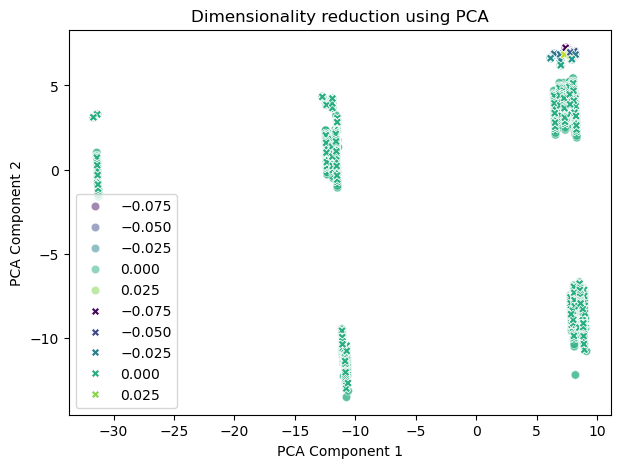

In [25]:
# Create the scatter plot with a continuous color range using "Spectral" palette
plt.figure(figsize=(7, 5))
scatter_train = sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train,  palette="viridis", alpha=0.5)
scatter_test = sns.scatterplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=y_test, palette="viridis", marker='X')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Dimensionality reduction using PCA')
plt.savefig("dataset_pca.png")

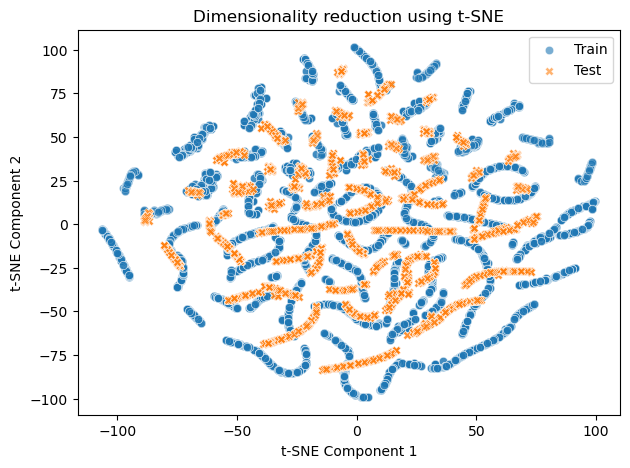

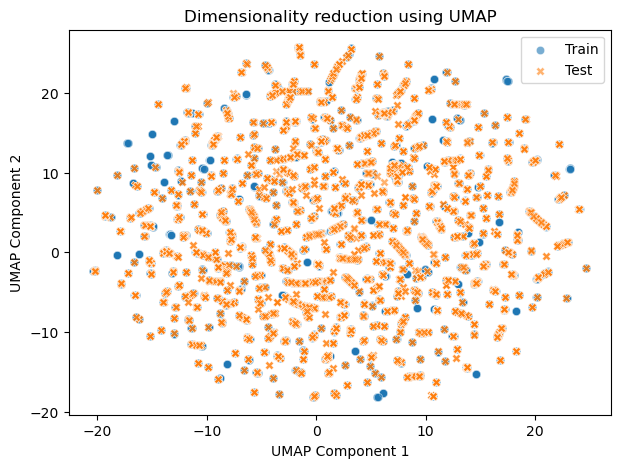

In [27]:
# Dimensionality reduction using t-SNE
tsne = TSNE(n_components=2)
X_train_tsne = tsne.fit_transform(X_train)
X_test_tsne = tsne.fit_transform(X_test)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_train_tsne[:, 0], y=X_train_tsne[:, 1], label='Train', alpha=0.6)
sns.scatterplot(x=X_test_tsne[:, 0], y=X_test_tsne[:, 1], label='Test', alpha=0.6, marker='X')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Dimensionality reduction using t-SNE')
plt.legend()
plt.show()

# Dimensionality reduction using UMAP
reducer = umap.UMAP()
X_train_umap = reducer.fit_transform(X_train)
X_test_umap = reducer.transform(X_test)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_train_umap[:, 0], y=X_train_umap[:, 1], label='Train', alpha=0.6)
sns.scatterplot(x=X_test_umap[:, 0], y=X_test_umap[:, 1], label='Test', alpha=0.6, marker='X')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.title('Dimensionality reduction using UMAP')
plt.legend()
plt.show()

In [31]:
X = np.concatenate([X_train, X_test], axis=0)
X_df = pd.DataFrame(X, columns=top5)

In [33]:
X_df

,doublecheck,t2start,t2mag,orbdiff,diag
0,3.103700e-02,-6.510431e-04,-3.127813,-41.657477,1.0
1,-2.236662e-05,5.106358e-07,-6.271769,-41.818623,0.0
2,-2.236662e-05,5.106358e-07,-6.271769,-41.818623,0.0
3,2.192688e-02,-4.490889e-04,-3.282063,-41.979770,1.0
4,-5.962675e-03,2.397402e-04,-3.580287,-22.684461,1.0
...,...,...,...,...,...
14795,-7.854473e-17,4.853761e-17,-16.474423,-2.341749,1.0
14796,3.875622e-02,-2.443025e-02,-1.704970,-1.964768,1.0
14797,9.602268e-06,-6.713584e-06,-5.345279,-2.126437,0.0
14798,9.602268e-06,-6.713584e-06,-5.345279,-2.126437,0.0


In [54]:
y_full = np.concatenate([y_train, y_test])
X_df['t2'] = y_full

In [55]:
cols = ['doublecheck', 't2start', 't2mag', 'orbdiff', 'diag', 't2']

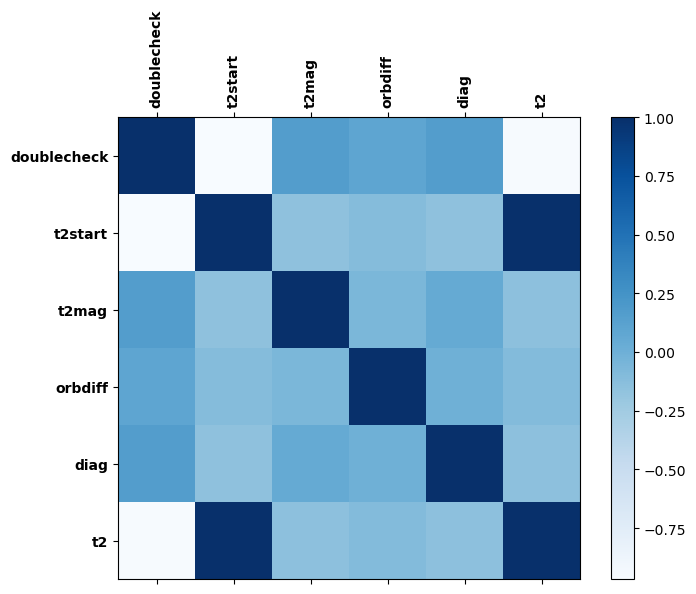

In [64]:
# Correlation matrix
corr = X_df.corr()

# Plot heatmap correctly
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(corr, cmap="Blues")

# Add colorbar
fig.colorbar(cax)

# Set ticks with feature names
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=90, fontsize=10, weight='bold')
ax.set_yticks(range(len(cols)))
ax.set_yticklabels(cols, fontsize=10, weight='bold')

plt.show()

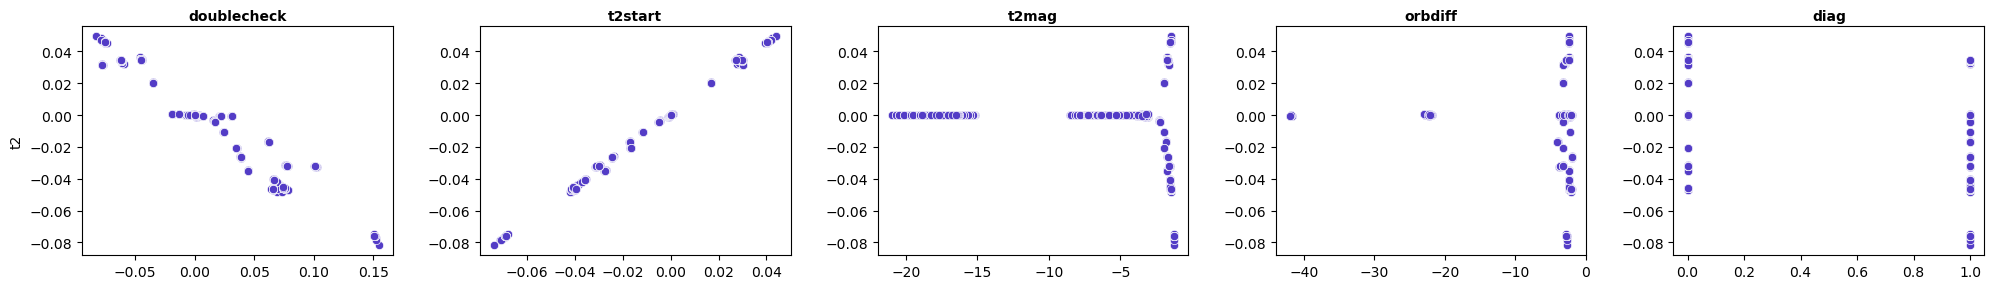

In [40]:
plot_df = X_df.copy()
target = 't2'

n_features = plot_df.shape[1] - 1  # exclude target
n_cols = 7
n_rows = (n_features - 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()  # Flatten to simplify indexing

for i, col in enumerate(plot_df.columns):
    if col == target:
        continue
    sns.scatterplot(
        x=plot_df[col],
        y=plot_df[target],
        ax=axes[i],
        color="xkcd:blue with a hint of purple",
        legend=False
    )
    axes[i].set_xlabel(col, fontweight='bold')
    axes[i].xaxis.set_label_position('top')
    axes[i].set_ylabel(target if i % n_cols == 0 else '')

for j in range(len(plot_df.columns)-1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
#plt.savefig("descriptors_vs_target_clean.png")
plt.show()

In [71]:
basis = "STO-3G"
n = 100
splits_fn = f"/mnt/c/Users/Maxim/Documents/Toronto/Research/code/DDLUCJ/data/{basis}_train_data_splits_{n}.pkl"
data = joblib.load(splits_fn)

X_train = data["X_train"]
y_train = data["y_train"]

splits_fn = f"/mnt/c/Users/Maxim/Documents/Toronto/Research/code/DDLUCJ/data/{basis}_test_data_splits.pkl"
data = joblib.load(splits_fn)
X_test = data["X_test"]
y_test = data["y_test"]

In [73]:
# SHAP feature importances
import shap
best_model = joblib.load('out/optimised_STO-3G_best_model_100.pkl')
tree_model = best_model.named_steps['xgb']

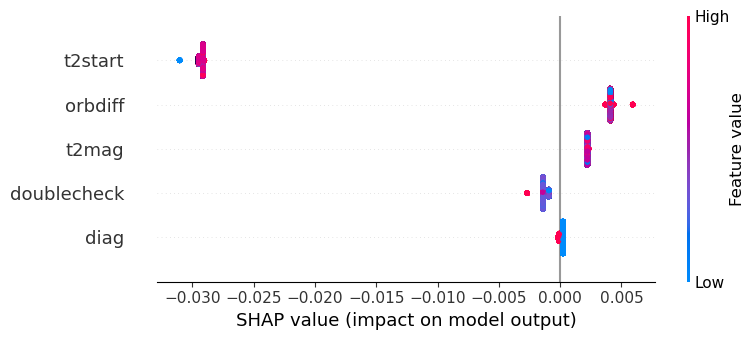

In [83]:
explainer = shap.TreeExplainer(tree_model)
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train, feature_names=top5)

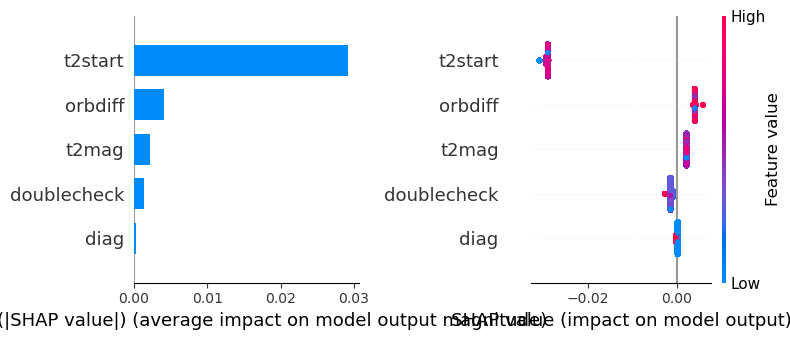

In [82]:
shap_values = explainer.shap_values(X_train)

plt.figure(figsize=(18,10))

# Bar plot
plt.subplot(1,2,1)
shap.summary_plot(
    shap_values, 
    X_train, 
    feature_names=top5,  
    plot_type='bar', 
    show=False
)
plt.gca().tick_params(axis='x', labelsize=10)

# Beeswarm plot
plt.subplot(1,2,2)
shap.summary_plot(
    shap_values, 
    X_train, 
    feature_names=top5,  
    show=False
)
plt.gca().tick_params(axis='x', labelsize=10)

plt.tight_layout()

In [ ]:
top5 = ['doublecheck', 't2start', 't2mag', 'orbdiff', 'diag']

In [80]:
tree_model.feature_importances_        # XGBoost feature importance values match the SHAP analysis

array([0.12930758, 0.79009914, 0.02735599, 0.04682388, 0.0064134 ],
      dtype=float32)

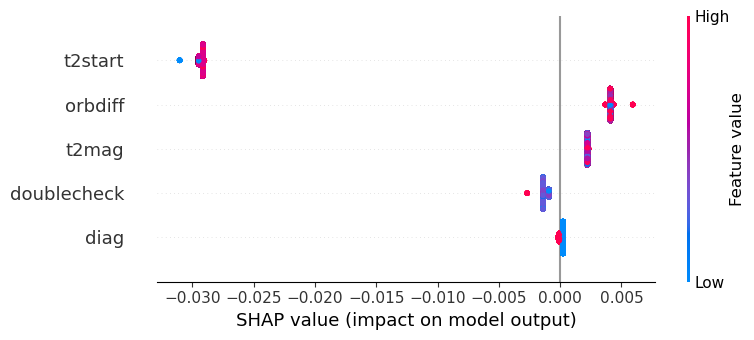

In [84]:
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=top5)